# Decision Tree Complexity: Investigating Overfitting
### Dataset: Titanic

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.tree import plot_tree

sns.set_style("whitegrid")

In [3]:
# Load Titanic dataset from seaborn
df = sns.load_dataset("titanic")

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### Select Features

In [5]:
features = ["pclass", "sex", "age", "fare"]

data = df[features + ["survived"]].dropna()

data["sex"] = data["sex"].map({"male":0, "female":1})

data.head()

,pclass,sex,age,fare,survived
0,3,0,22.0,7.2500,0
1,1,1,38.0,71.2833,1
2,3,1,26.0,7.9250,1
3,1,1,35.0,53.1000,1
4,3,0,35.0,8.0500,0


### Dataset Distribution Plot

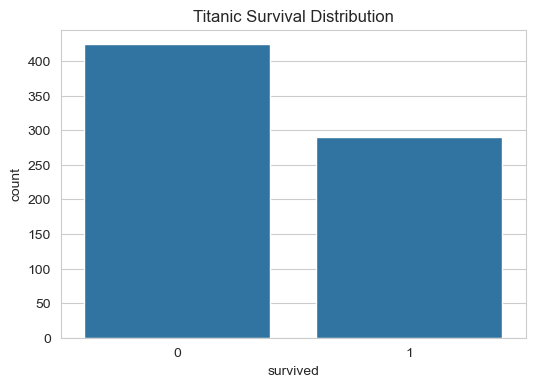

In [7]:
plt.figure(figsize=(6,4))

sns.countplot(data=data, x="survived")

plt.title("Titanic Survival Distribution")

plt.savefig("titanic_dataset_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

### Feature Matrix

In [9]:
X = data[features]
y = data["survived"]

### Train Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

### Decision Tree Depth = 1

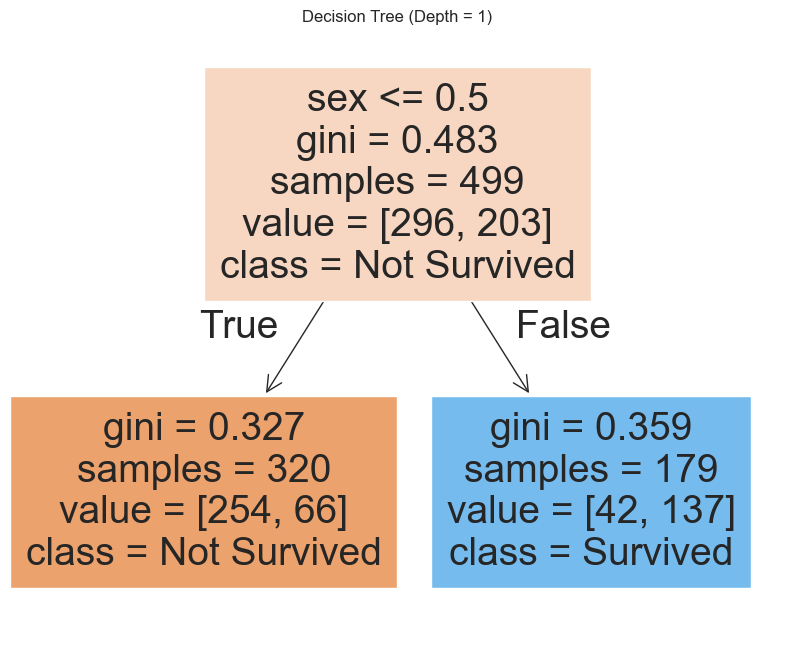

In [13]:
tree_depth1 = DecisionTreeClassifier(max_depth=1, random_state=42)

tree_depth1.fit(X_train, y_train)

plt.figure(figsize=(10,8))

plot_tree(
    tree_depth1,
    feature_names=features,
    class_names=["Not Survived","Survived"],
    filled=True
)

plt.title("Decision Tree (Depth = 1)")

plt.savefig("tree_depth_1.png", dpi=300, bbox_inches="tight")

plt.show()

### Decision Tree Depth = 3

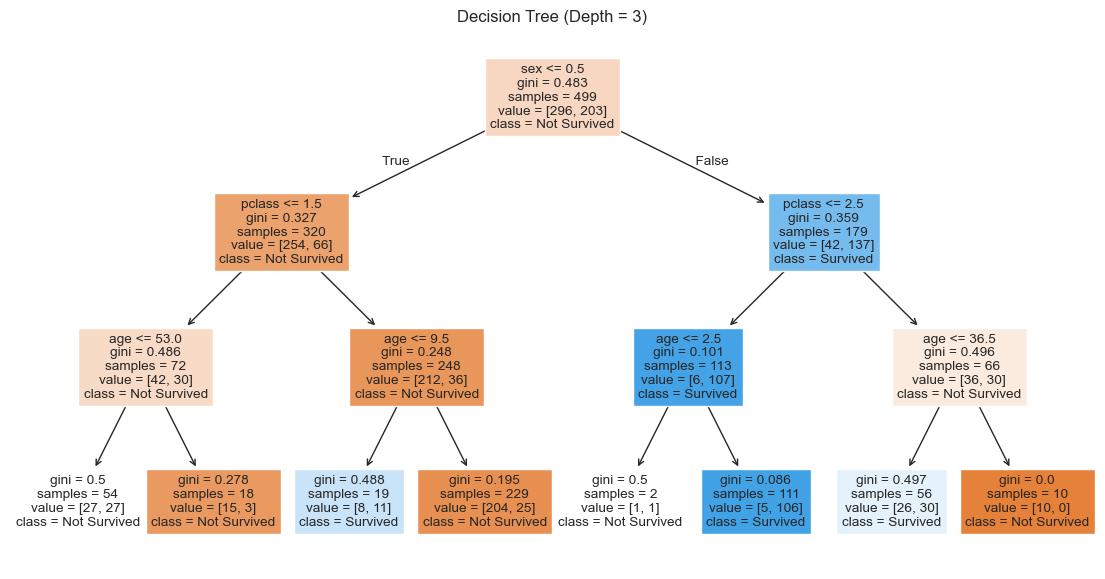

In [15]:
tree_depth3 = DecisionTreeClassifier(max_depth=3, random_state=42)

tree_depth3.fit(X_train, y_train)

plt.figure(figsize=(14,7))

plot_tree(
    tree_depth3,
    feature_names=features,
    class_names=["Not Survived","Survived"],
    filled=True
)

plt.title("Decision Tree (Depth = 3)")

plt.savefig("tree_depth_3.png", dpi=300, bbox_inches="tight")

plt.show()

### Decision Tree Depth = 10

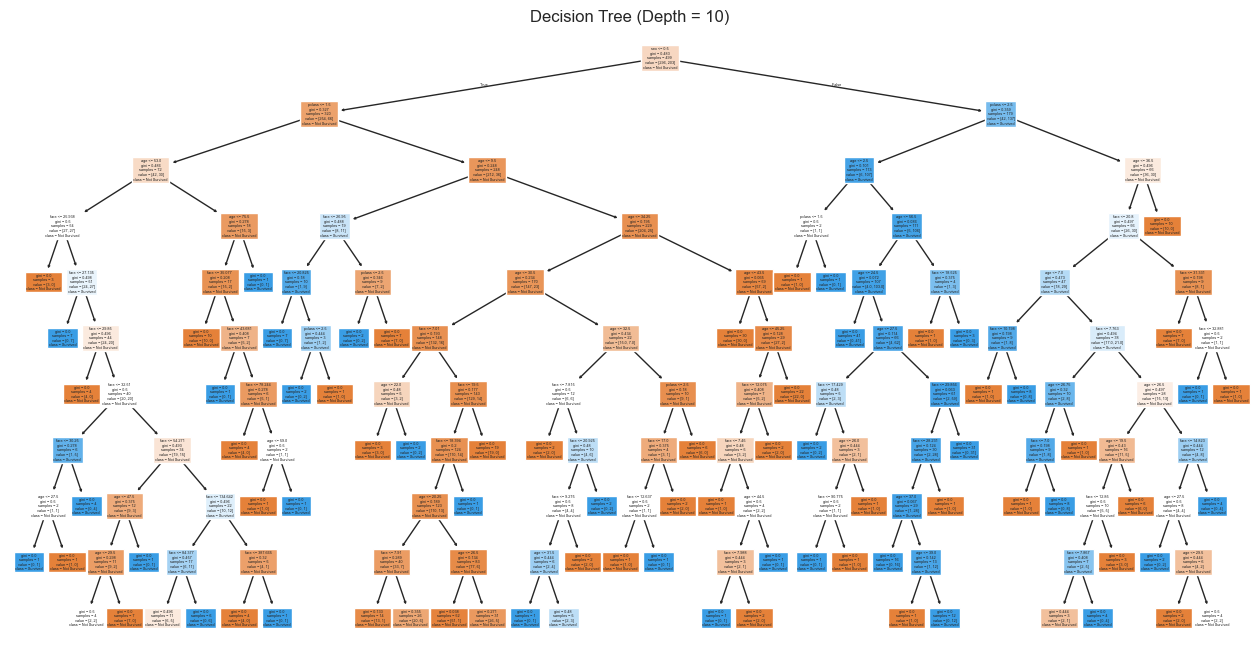

In [17]:
tree_depth10 = DecisionTreeClassifier(max_depth=10, random_state=42)

tree_depth10.fit(X_train, y_train)

plt.figure(figsize=(16,8))

plot_tree(
    tree_depth10,
    feature_names=features,
    class_names=["Not Survived","Survived"],
    filled=True
)

plt.title("Decision Tree (Depth = 10)")

plt.savefig("tree_depth_10.png", dpi=300, bbox_inches="tight")

plt.show()

### Accuracy vs Tree Depth

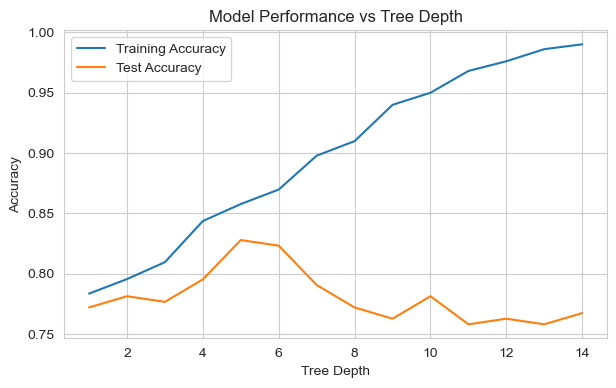

In [19]:
train_acc = []
test_acc = []

depths = range(1,15)

for d in depths:

    model = DecisionTreeClassifier(max_depth=d, random_state=42)

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_acc.append(accuracy_score(y_train, train_pred))
    test_acc.append(accuracy_score(y_test, test_pred))

plt.figure(figsize=(7,4))

plt.plot(depths, train_acc, label="Training Accuracy")
plt.plot(depths, test_acc, label="Test Accuracy")

plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")

plt.title("Model Performance vs Tree Depth")

plt.legend()

plt.savefig("accuracy_vs_depth.png", dpi=300, bbox_inches="tight")

plt.show()

### Feature Importance Plot

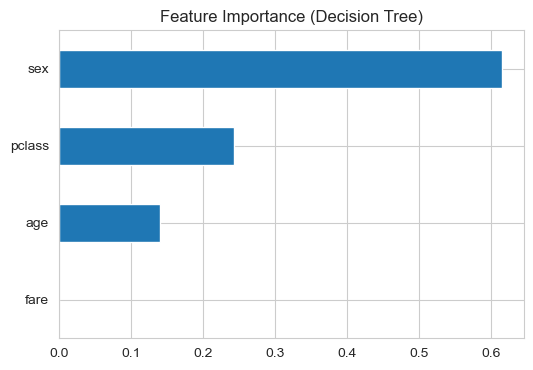

In [21]:
model = DecisionTreeClassifier(max_depth=3, random_state=42)

model.fit(X_train, y_train)

importances = model.feature_importances_

feat_imp = pd.Series(importances, index=features).sort_values()

plt.figure(figsize=(6,4))

feat_imp.plot(kind="barh")

plt.title("Feature Importance (Decision Tree)")

plt.savefig("feature_importance.png", dpi=300, bbox_inches="tight")

plt.show()

### Model Performance

In [23]:
models = {
    "Depth 1": tree_depth1,
    "Depth 3": tree_depth3,
    "Depth 10": tree_depth10
}

results = []

for name, model in models.items():

    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred)
    rec = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)

    results.append([name, acc, prec, rec, f1])

results_df = pd.DataFrame(
    results,
    columns=["Model","Accuracy","Precision","Recall","F1 Score"]
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Depth 1,0.772093,0.731707,0.689655,0.710059
1,Depth 3,0.776744,0.719101,0.735632,0.727273
2,Depth 10,0.781395,0.743902,0.701149,0.721893
